# 🎣 Phishing Detection with Fine-Tuned SLMs

> **Goal:** Fine-tune a small language model (Qwen3 0.6B) to classify webpages as *phishing* or *benign* using URL + cleaned HTML features.

---

## 1 · Environment Setup

In [ ]:
%%capture
!pip install unsloth lxml 

In [14]:
import os
os.environ['HF_HUB_DISABLE_XET'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'true'

## 2 · Imports

In [15]:
import re
import gc
import random
from urllib.parse import urlparse
from collections import Counter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from lxml import html as lxml_html, etree

from unsloth import FastLanguageModel
from datasets import load_dataset, concatenate_datasets, Dataset
from transformers import set_seed
from trl import SFTTrainer, SFTConfig
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

---

## 3 · Helper Functions

| Function | Purpose |
|---|---|
| `clean_html` | Strips noisy tags, keeps only phishing-relevant elements (`title`, `input`, `iframe`) |
| `url_features` / `html_features` | Extract lightweight heuristic signals for EDA |
| `preprocess_function` | Builds chat-templated strings for SFT training & inference |
| `plot_*` / `evaluate_model` | Visualization & evaluation utilities |
| `evaluate_few_shot` | Few-shot in-context evaluation using training examples as demonstrations |

In [16]:
def set_all_seeds(seed: int):
    # Lock every RNG source (Python, NumPy, Torch CPU/GPU, HF) so runs are reproducible.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)
    # Force deterministic cuDNN kernels at the cost of some throughput.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_all_seeds(42)


# Tags whose presence/structure carries phishing signal; everything else is dropped.
KEEP_TAGS = {"title", "input", "iframe"}
# Small attribute allowlist: form targets, input types, embed sources.
KEEP_ATTRS = frozenset({"type", "src", "action"})
# Pure-noise tags that mostly inflate token counts without classification value.
_REMOVE_TAGS = {"script", "style", "noscript"}


def clean_html(raw_html: str) -> str:
    # Compress raw HTML into a tiny phishing-relevant view: parse, prune noisy
    # subtrees, drop non-allowlisted attributes, and serialize only KEEP_TAGS.
    try:
        doc = lxml_html.fromstring(raw_html)
    except Exception:
        return ""
    # Pass 1: physically remove script/style/noscript subtrees from the DOM.
    for el in list(doc.iter()):
        if not isinstance(el.tag, str) or el.tag in _REMOVE_TAGS:
            p = el.getparent()
            if p is not None:
                p.remove(el)
    # Pass 2: strip every attribute that isn't in the small allowlist.
    for el in doc.iter():
        if isinstance(el.tag, str):
            for k in [a for a in el.attrib if a not in KEEP_ATTRS]:
                try:
                    del el.attrib[k]
                except (ValueError, KeyError):
                    pass
    # Pass 3: serialize only elements whose tag is in KEEP_TAGS.
    parts = [
        etree.tostring(el, encoding="unicode", method="html", with_tail=False)
        for el in doc.iter()
        if isinstance(el.tag, str) and el.tag in KEEP_TAGS
    ]
    return "\n".join(parts)


def url_features(urls):
    # Extract simple URL-level signals (TLD, length, depth, suspicious markers)
    # used downstream to compare phish vs benign distributions.
    tlds, url_lens, path_depths = [], [], []
    has_hyphen = has_ip = has_at = 0
    for url in urls:
        p = urlparse(url)
        domain = p.netloc
        parts = domain.split(".")
        if len(parts) >= 2:
            tlds.append(parts[-1])
        url_lens.append(len(url))
        path_depths.append(len([s for s in p.path.split("/") if s]))
        # Classic phishing heuristics: hyphenated domain, raw IP host, '@' in URL.
        has_hyphen += "-" in domain
        has_ip += bool(re.match(r"\d+\.\d+\.\d+\.\d+", domain))
        has_at += "@" in url
    return tlds, url_lens, path_depths, has_hyphen, has_ip, has_at


# One alternation regex is much faster than parsing each HTML doc with lxml.
_re_tags = re.compile(
    r"<a\s[^>]*href\s*=|<img[\s>]|<script[\s>]|<form[\s>]"
    r"|<input\s[^>]*type\s*=\s*[\"']?password|<input[\s>]",
    re.IGNORECASE,
)


def html_features(htmls):
    # Count phishing-relevant tags (links, images, scripts, forms, inputs,
    # password fields) using a single regex pass per document.
    lengths, n_links, n_images, n_scripts, n_forms, n_inputs, n_pw = [], [], [], [], [], [], []
    for h in htmls:
        links = imgs = scripts = forms = inputs = pw = 0
        for m in _re_tags.finditer(h):
            # Dispatch on the first char after '<' to identify which alt matched.
            tag_char = m.group()[1].lower()
            if tag_char == "a": links += 1
            elif tag_char == "i":
                s = m.group()
                if s[2].lower() == "m": imgs += 1
                # Password input is a strong phishing indicator; track separately.
                elif "password" in s.lower(): pw += 1; inputs += 1
                else: inputs += 1
            elif tag_char == "s": scripts += 1
            elif tag_char == "f": forms += 1
        lengths.append(len(h)); n_links.append(links); n_images.append(imgs)
        n_scripts.append(scripts); n_forms.append(forms); n_inputs.append(inputs); n_pw.append(pw)
    return lengths, n_links, n_images, n_scripts, n_forms, n_inputs, n_pw


def preprocess_function(examples):
    # Build two chat-templated strings per row:
    #   * 'text'   = user prompt + gold assistant answer (used for SFT loss)
    #   * 'prompt' = user prompt with generation marker (used at eval time)
    # Relies on `tokenizer` and `prompt_template` defined in later cells.
    texts   = []
    prompts = []
    for url, html, label in zip(examples["url"], examples["html"], examples["label"]):
        user_content = prompt_template.format(url=url, html=html)
        messages = [
            {"role": "user",      "content": user_content},
            {"role": "assistant", "content": f"<prediction>{label}</prediction>"},
        ]
        # Full conversation incl. gold answer -> training target.
        texts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False, enable_thinking=False))
        # User-only conversation with generation prompt -> inference input.
        prompts.append(tokenizer.apply_chat_template(
            [{"role": "user", "content": user_content}],
            tokenize=False, add_generation_prompt=True, enable_thinking=False,
        ))
    return {"text": texts, "prompt": prompts}


def plot_url_analysis(dataset):
    all_labels = dataset["label"]
    all_urls   = dataset["url"]

    phish_idx  = [i for i, l in enumerate(all_labels) if l == "phish"]
    benign_idx = [i for i, l in enumerate(all_labels) if l == "benign"]
    phish_urls  = [all_urls[i] for i in phish_idx]
    benign_urls = [all_urls[i] for i in benign_idx]

    p_tlds, p_lens, p_depths, p_hyp, p_ip, p_at = url_features(phish_urls)
    b_tlds, b_lens, b_depths, b_hyp, b_ip, b_at = url_features(benign_urls)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    p_tld_counts = Counter(p_tlds)
    b_tld_counts = Counter(b_tlds)
    all_top_tlds = [t for t, _ in (p_tld_counts + b_tld_counts).most_common(10)]
    x, w = np.arange(len(all_top_tlds)), 0.35
    axes[0].bar(x - w/2, [100 * p_tld_counts[t] / len(p_tlds) for t in all_top_tlds], w, label="Phish", color="crimson", alpha=0.8)
    axes[0].bar(x + w/2, [100 * b_tld_counts[t] / len(b_tlds) for t in all_top_tlds], w, label="Benign", color="steelblue", alpha=0.8)
    axes[0].set_xticks(x); axes[0].set_xticklabels([f".{t}" for t in all_top_tlds], rotation=45)
    axes[0].set_ylabel("% of class"); axes[0].set_title("TLD Distribution"); axes[0].legend()

    lo, hi = np.percentile(p_lens + b_lens, 1), np.percentile(p_lens + b_lens, 99)
    shared_bins = np.linspace(lo, hi, 40)
    axes[1].hist([l for l in p_lens if lo <= l <= hi], bins=shared_bins, alpha=0.6, label="Phish", color="crimson", density=True)
    axes[1].hist([l for l in b_lens if lo <= l <= hi], bins=shared_bins, alpha=0.6, label="Benign", color="steelblue", density=True)
    axes[1].set_xlabel("URL length (chars)"); axes[1].set_ylabel("Density")
    axes[1].set_title("URL Length Distribution"); axes[1].legend()

    max_depth = 8
    x4 = np.arange(max_depth + 1)
    axes[2].bar(x4 - w/2, [sum(1 for d in p_depths if d == i) / max(len(p_depths), 1) * 100 for i in range(max_depth + 1)], w, label="Phish", color="crimson", alpha=0.8)
    axes[2].bar(x4 + w/2, [sum(1 for d in b_depths if d == i) / max(len(b_depths), 1) * 100 for i in range(max_depth + 1)], w, label="Benign", color="steelblue", alpha=0.8)
    axes[2].set_xlabel("Path depth"); axes[2].set_ylabel("% of class")
    axes[2].set_title("URL Path Depth"); axes[2].legend()

    plt.suptitle("Phishing vs Benign: URL Signal Analysis", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()

    print(f"Phish:  hyphen={100*p_hyp/max(len(p_lens),1):.1f}%, avg_len={np.mean(p_lens):.1f}, avg_depth={np.mean(p_depths):.1f}")
    print(f"Benign: hyphen={100*b_hyp/max(len(b_lens),1):.1f}%, avg_len={np.mean(b_lens):.1f}, avg_depth={np.mean(b_depths):.1f}")


def plot_training_curves(trainer):
    # Plot training/eval loss from trainer.state.log_history.
    # The Trainer interleaves per-step train logs and per-eval-step eval logs in
    # the same list, so we split them by which keys each entry exposes.
    history = trainer.state.log_history
    train_steps, train_loss = [], []
    eval_steps, eval_loss = [], []
    for entry in history:
        step = entry.get("step")
        # Training log: has 'loss' but no 'eval_loss'.
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(step)
            train_loss.append(entry["loss"])
        # Evaluation log: has 'eval_loss' (sparser, every eval_steps).
        if "eval_loss" in entry:
            eval_steps.append(step)
            eval_loss.append(entry["eval_loss"])

    fig, ax = plt.subplots(figsize=(8, 4))

    # Loss curves: dense train trace overlaid with sparser eval points.
    ax.plot(train_steps, train_loss, label="train", color="steelblue", marker="o", markersize=3)
    if eval_loss:
        ax.plot(eval_steps, eval_loss, label="eval", color="crimson", marker="s", markersize=5)
    ax.set_xlabel("Step"); ax.set_ylabel("Loss")
    ax.set_title("Training / Eval Loss"); ax.legend(); ax.grid(alpha=0.3)

    plt.suptitle("Training Curves", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()


def evaluate_model(model, tokenizer, eval_ds, batch_size=16, max_new_tokens=48):
    # Run the model on a held-out split, parse <prediction>…</prediction> outputs,
    # and report classification metrics.
    gc.collect()
    torch.cuda.empty_cache()

    FastLanguageModel.for_inference(model)
    # Decoder-only models need left padding so generation continues from the right edge.
    tokenizer.padding_side = "left"

    prompts = eval_ds["prompt"]   # pre-built at preprocessing time
    labels  = eval_ds["label"]

    all_responses = []
    import warnings
    with torch.inference_mode(), warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=".*max_new_tokens.*max_length.*")
        warnings.filterwarnings("ignore", category=FutureWarning, module="transformers.modeling_attn_mask_utils")
        for i in tqdm(range(0, len(prompts), batch_size)):
            inputs = tokenizer(
                prompts[i : i + batch_size],
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_seq_length,
            ).to(model.device)

            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,  # greedy decoding -> deterministic eval
                pad_token_id=tokenizer.pad_token_id,
            )

            # Slice off the prompt tokens so we only decode the freshly generated answer.
            new_tokens = [out[len(inp):] for inp, out in zip(inputs.input_ids, outputs)]
            all_responses.extend(tokenizer.batch_decode(new_tokens, skip_special_tokens=True))

            del inputs, outputs, new_tokens
            torch.cuda.empty_cache()

    # Pull the label out of the XML tag; fall back to raw text when the tag is missing.
    pred_re = re.compile(r"<prediction>(.*?)</prediction>")
    parsed = [
        m.group(1).strip().lower() if (m := pred_re.search(r)) else r.strip().lower()
        for r in all_responses
    ]

    # Compute precision/recall/F1 only over rows the model classified validly.
    valid_mask  = [p in ("phish", "benign") for p in parsed]
    valid_labels = [l for l, v in zip(labels, valid_mask) if v]
    valid_preds  = [p for p, v in zip(parsed, valid_mask) if v]

    acc = accuracy_score(labels, parsed)
    print(f"Accuracy:  {100 * acc:.2f}%")

    if valid_preds:
        print(f"Precision: {100 * precision_score(valid_labels, valid_preds, pos_label='phish'):.2f}%")
        print(f"Recall:    {100 * recall_score(valid_labels, valid_preds, pos_label='phish'):.2f}%")
        print(f"F1:        {100 * f1_score(valid_labels, valid_preds, pos_label='phish'):.2f}%")
        cm = confusion_matrix(valid_labels, valid_preds, labels=["benign", "phish"])
        print(f"\nConfusion matrix (rows=true, cols=pred):")
        print(pd.DataFrame(cm, index=["true_benign", "true_phish"], columns=["pred_benign", "pred_phish"]))

    invalid_count = len(parsed) - len(valid_preds)
    if invalid_count:
        print(f"\nInvalid responses: {invalid_count}/{len(all_responses)}")
        print(f"Examples: {[r for r, v in zip(all_responses, valid_mask) if not v][:5]}")

    return {"responses": all_responses, "parsed": parsed, "labels": labels, "accuracy": acc}


def evaluate_few_shot(model, tokenizer, train_ds, eval_ds, prompt_template,
                      n_shots=3, max_seq_length=4096, batch_size=8, max_new_tokens=48, seed=42):
    """Evaluate the model on eval_ds using n_shots examples from train_ds as in-context demonstrations.

    Samples balanced few-shot examples (ceil(n/2) phish, rest benign), constructs
    a multi-turn chat with alternating user/assistant pairs for the demos, then
    appends the test sample as the final user turn for generation.
    """
    gc.collect()
    torch.cuda.empty_cache()

    FastLanguageModel.for_inference(model)
    tokenizer.padding_side = "left"

    rng = random.Random(seed)
    phish_indices = [i for i, l in enumerate(train_ds["label"]) if l == "phish"]
    benign_indices = [i for i, l in enumerate(train_ds["label"]) if l == "benign"]
    n_phish = (n_shots + 1) // 2
    n_benign = n_shots - n_phish
    shot_indices = rng.sample(phish_indices, n_phish) + rng.sample(benign_indices, n_benign)
    rng.shuffle(shot_indices)

    demo_messages = []
    for idx in shot_indices:
        row = train_ds[idx]
        demo_messages.append({"role": "user", "content": prompt_template.format(url=row["url"], html=row["html"])})
        demo_messages.append({"role": "assistant", "content": f"<prediction>{row['label']}</prediction>"})

    prompts = []
    for url, html in zip(eval_ds["url"], eval_ds["html"]):
        test_msg = {"role": "user", "content": prompt_template.format(url=url, html=html)}
        messages = demo_messages + [test_msg]
        prompts.append(tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True, enable_thinking=False,
        ))

    labels = eval_ds["label"]

    all_responses = []
    import warnings
    with torch.inference_mode(), warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=".*max_new_tokens.*max_length.*")
        warnings.filterwarnings("ignore", category=FutureWarning, module="transformers.modeling_attn_mask_utils")
        for i in tqdm(range(0, len(prompts), batch_size)):
            inputs = tokenizer(
                prompts[i : i + batch_size],
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_seq_length,
            ).to(model.device)

            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
            )

            new_tokens = [out[len(inp):] for inp, out in zip(inputs.input_ids, outputs)]
            all_responses.extend(tokenizer.batch_decode(new_tokens, skip_special_tokens=True))

            del inputs, outputs, new_tokens
            torch.cuda.empty_cache()

    pred_re = re.compile(r"<prediction>(.*?)</prediction>")
    parsed = [
        m.group(1).strip().lower() if (m := pred_re.search(r)) else r.strip().lower()
        for r in all_responses
    ]

    valid_mask = [p in ("phish", "benign") for p in parsed]
    valid_labels = [l for l, v in zip(labels, valid_mask) if v]
    valid_preds = [p for p, v in zip(parsed, valid_mask) if v]

    print(f"Few-shot evaluation ({n_shots} shots):")
    acc = accuracy_score(labels, parsed)
    print(f"Accuracy:  {100 * acc:.2f}%")

    if valid_preds:
        print(f"Precision: {100 * precision_score(valid_labels, valid_preds, pos_label='phish'):.2f}%")
        print(f"Recall:    {100 * recall_score(valid_labels, valid_preds, pos_label='phish'):.2f}%")
        print(f"F1:        {100 * f1_score(valid_labels, valid_preds, pos_label='phish'):.2f}%")
        cm = confusion_matrix(valid_labels, valid_preds, labels=["benign", "phish"])
        print(f"\nConfusion matrix (rows=true, cols=pred):")
        print(pd.DataFrame(cm, index=["true_benign", "true_phish"], columns=["pred_benign", "pred_phish"]))

    invalid_count = len(parsed) - len(valid_preds)
    if invalid_count:
        print(f"\nInvalid responses: {invalid_count}/{len(all_responses)}")
        print(f"Examples: {[r for r, v in zip(all_responses, valid_mask) if not v][:5]}")

    return {"responses": all_responses, "parsed": parsed, "labels": labels, "accuracy": acc}

---

## 4 · Data Loading & Exploration

Stream **5 000** samples from `phreshphish/phreshphish`, clean HTML on-the-fly, and drop pages exceeding 5 000 chars.

In [17]:
# Clean HTML is applied during streaming so raw HTML never touches RAM
N_SAMPLES = 5000
MAX_HTML_LEN = 5_000
KEEP_FIELDS = {"url", "label", "lang"}

stream = load_dataset("phreshphish/phreshphish", split="train", streaming=True)

rows = []
for row in stream.take(N_SAMPLES):
    cleaned = clean_html(row["html"])
    if len(cleaned) > MAX_HTML_LEN:
        continue
    rows.append({**{k: row[k] for k in KEEP_FIELDS}, "html": cleaned})

sampled = Dataset.from_list(rows)
del rows
gc.collect()

print(f"Sampled {len(sampled)} examples (after HTML length filter)")
print(f"Columns: {sampled.column_names}")
print(sampled[0])

Resolving data files:   0%|          | 0/56 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/56 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Sampled 4897 examples (after HTML length filter)
Columns: ['url', 'lang', 'label', 'html']
{'url': 'https://moneypuck.com/goalies.htm', 'lang': 'en', 'label': 'benign', 'html': '<title>NHL Goalie Advanced Stats 2024-2025</title>\n<input type="range">\n<iframe src="https://googleads.g.doubleclick.net/pagead/ads?client=ca-pub-1085579666653840&amp;output=html&amp;adk=1812271804&amp;adf=3025194257&amp;lmt=1751340913&amp;plaf=2%3A2%2C7%3A2&amp;plat=2%3A16777216%2C3%3A128%2C4%3A128%2C8%3A128%2C9%3A32776%2C16%3A8388608%2C17%3A32%2C24%3A32%2C25%3A32%2C30%3A1081344%2C32%3A32%2C41%3A32%2C42%3A32&amp;format=0x0&amp;url=https%3A%2F%2Fmoneypuck.com%2Fgoalies.htm&amp;pra=5&amp;wgl=1&amp;aihb=0&amp;asro=0&amp;aifxl=29_18~30_19&amp;aiapm=0.1542&amp;aiapmd=0.25178&amp;aiapmi=0.16&amp;aiapmid=1&amp;aiact=0.5423&amp;aiactd=0.7&amp;aicct=0.7&amp;aicctd=0.5799&amp;ailct=0.5849&amp;ailctd=0.65&amp;aimart=4&amp;aimartd=4&amp;abgtt=6&amp;dt=1756798343934&amp;bpp=7&amp;bdt=1448&amp;idt=837&amp;shv=r20250827&am

Filter to **English-only** pages and inspect label balance.

In [18]:
print(f"=== Raw sampled dataset ===")
print(f"Total samples: {len(sampled)}")
lang_counts = pd.Series(sampled['lang']).value_counts()
english_count = lang_counts.get('en', 0)
print(f"English: {english_count} ({english_count/len(sampled)*100:.1f}%) | Other: {len(sampled) - english_count}")
print(f"Labels: {pd.Series(sampled['label']).value_counts().to_string()}")
print()

dataset = sampled.filter(lambda x: x["lang"] == "en")
del sampled
gc.collect()

non_english_count = len(dataset) # already know from above, just print relative
print(f"=== After language filter ===")
print(f"Kept: {len(dataset)} English samples")
print(f"Labels: {pd.Series(dataset['label']).value_counts().to_string()}")

=== Raw sampled dataset ===
Total samples: 4897
English: 4096 (83.6%) | Other: 801
Labels: benign    2718
phish     2179



Filter:   0%|          | 0/4897 [00:00<?, ? examples/s]

=== After language filter ===
Kept: 4096 English samples
Labels: benign    2427
phish     1669


**URL-level signal analysis** — TLD distribution, URL length, and path depth for phish vs. benign.

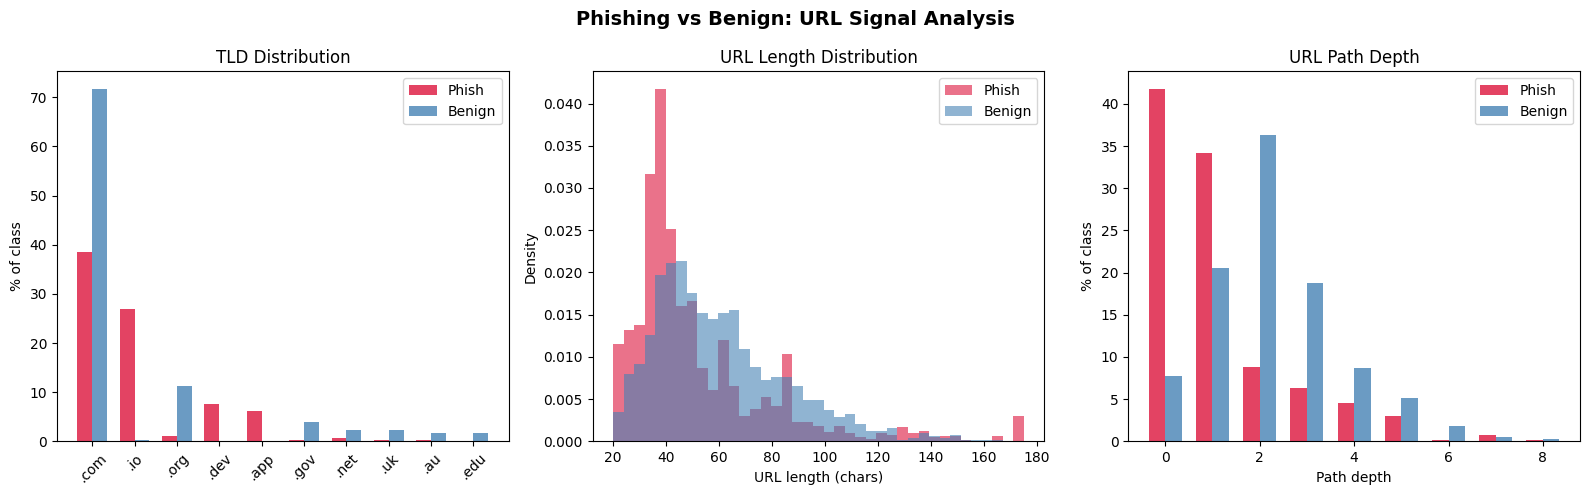

Phish:  hyphen=45.2%, avg_len=57.1, avg_depth=1.2
Benign: hyphen=3.6%, avg_len=60.1, avg_depth=2.3


In [19]:
plot_url_analysis(dataset)

---

## 5 · Class Balancing

Downsample the majority class to match the minority.

In [20]:
benign = dataset.filter(lambda x: x["label"] == "benign")
phish  = dataset.filter(lambda x: x["label"] == "phish")
min_count = min(len(benign), len(phish))
del dataset
gc.collect()

print(f"=== Balancing ===")
print(f"Before: benign={len(benign)}, phish={len(phish)}")
print(f"Downsampling to {min_count} per class")

benign = benign.shuffle(seed=42).select(range(min_count))
phish  = phish.shuffle(seed=42).select(range(min_count))
balanced = concatenate_datasets([benign, phish]).shuffle(seed=42)
del benign, phish
gc.collect()

print(f"\n=== Final balanced dataset ===")
print(f"Total: {len(balanced)} samples")
print(f"Labels: {pd.Series(balanced['label']).value_counts().to_string()}")

Filter:   0%|          | 0/4096 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4096 [00:00<?, ? examples/s]

=== Balancing ===
Before: benign=2427, phish=1669
Downsampling to 1669 per class

=== Final balanced dataset ===
Total: 3338 samples
Labels: benign    1669
phish     1669


Train / Val / Test split — **80 / 10 / 10**.

In [21]:
train_test = balanced.train_test_split(test_size=0.2, seed=42)
train_ds   = train_test["train"]
test_val   = train_test["test"].train_test_split(test_size=0.5, seed=42)
val_ds     = test_val["train"]
test_ds    = test_val["test"]
del balanced, train_test, test_val
gc.collect()

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
for name, ds in [("Train", train_ds), ("Val", val_ds), ("Test", test_ds)]:
    counts = pd.Series(ds["label"]).value_counts()
    print(f"  {name}: benign={counts.get('benign', 0)}, phish={counts.get('phish', 0)}")

Train: 2670 | Val: 334 | Test: 334
  Train: benign=1310, phish=1360
  Val: benign=178, phish=156
  Test: benign=181, phish=153


---

## 6 · Model & LoRA Setup

Load **Qwen3-0.6B** in 4-bit and attach a rank-16 LoRA adapter to all attention + MLP projections.

In [22]:
max_seq_length = 4096
model_id = "unsloth/Qwen3-0.6B-unsloth-bnb-4bit"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_id,
    max_seq_length=max_seq_length,
    load_in_4bit=True,
    load_in_8bit=False,
)

==((====))==  Unsloth 2026.4.8: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA B200. Num GPUs = 2. Max memory: 178.351 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 10.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

unsloth/Qwen3-0.6B-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Apply LoRA adapter.

In [23]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
    max_seq_length=max_seq_length,
)

---

## 7 · Prompt Template & Preprocessing

Define the classification prompt and tokenize all splits into chat-formatted strings.

In [24]:
prompt_template = """Analyze the following webpage and determine if it is a phishing page or a benign (legitimate) page.

URL: {url}

HTML content:
{html}

Classify this webpage as either "phish" or "benign". Output your prediction in XML format: <prediction>phish</prediction> or <prediction>benign</prediction>"""

### Few-shot baseline on test set

Evaluate the **untrained** model on the test set using **5 few-shot** in-context examples drawn from the training split. This measures whether providing demonstrations alone (without fine-tuning) can improve over zero-shot.

In [ ]:
# few_shot_results = evaluate_few_shot(
#     model, tokenizer, train_ds, test_ds, prompt_template,
#     n_shots=5, max_seq_length=max_seq_length,
# )

100%|██████████| 42/42 [00:58<00:00,  1.38s/it]

Few-shot evaluation (10 shots):
Accuracy:  64.37%
Precision: 71.03%
Recall:    50.67%
F1:        59.14%

Confusion matrix (rows=true, cols=pred):
             pred_benign  pred_phish
true_benign          139          31
true_phish            74          76

Invalid responses: 14/334
Examples: ['=1&amp;v=1&amp;v=1&amp;v=1&amp;v=1&amp;v=1&amp;v=1&amp;v=1&amp;v=1&amp;v=1&amp', '4118021343;npa=0;auiddc=560133611.1745868101;u4=undefined;u5', 'iframe src="https://www.google.com/ads/adsense/ads?utm_source=bankrate&amp;utm_medium=ads&amp;utm_campaign=bankrate&amp;adgroupid=100000000', '16777216%2C16%3A16777216%2C16%3A16777216%2C16%3A', 'opes-ym%22%2C%22mbr-req%22%2C%22mbr-req%22%2C%22mbr-req%22%2C']


Tokenize all splits into chat-formatted strings.

In [ ]:
# Map and immediately drop heavy raw columns to free RAM
train_ds = train_ds.map(preprocess_function, batched=True, batch_size=32)
train_ds = train_ds.remove_columns(["url", "html"])
gc.collect()

val_ds = val_ds.map(preprocess_function, batched=True, batch_size=32)
val_ds = val_ds.remove_columns(["url", "html"])
gc.collect()

test_ds = test_ds.map(preprocess_function, batched=True, batch_size=32)
test_ds = test_ds.remove_columns(["url", "html"])
gc.collect()

print(f"Columns after preprocessing — Train: {train_ds.column_names}")
print("Sample formatted text:")
print(train_ds[0]["text"][:1000])

---

## 8 · Baseline Evaluation (Before Fine-Tuning)

Run the **untrained** model on the validation set to establish a performance floor.

In [ ]:
results = evaluate_model(model, tokenizer, test_ds)

---

## 9 · SFT Training

**100 steps** with sequence packing, 8-bit AdamW, constant LR with warmup.

In [ ]:
training_args = SFTConfig(
    # Core training setup
    output_dir="./results",
    max_steps=100,
    max_seq_length=max_seq_length,
    packing=True,

    # Batch size / effective batch size
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=2,

    # Optimization
    optim="adamw_8bit",
    learning_rate=5e-04,
    lr_scheduler_type="constant_with_warmup",
    warmup_steps=5,
    weight_decay=0.1,
    max_grad_norm=0.8,

    # Precision
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),

    # Evaluation
    eval_strategy="steps",
    eval_steps=10,

    # Logging
    logging_strategy="steps",
    logging_steps=10,
    logging_dir="./logs",
    report_to="none",

    # Saving
    save_strategy="no",

    # Reproducibility
    seed=42,
    data_seed=42,
)

Initialize trainer.

In [ ]:
FastLanguageModel.for_training(model)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    formatting_func=lambda examples: examples["text"],
)
trainer.can_return_loss = True

Run training.

In [ ]:
train_result = trainer.train()


Training loss & LR schedule curves.

In [ ]:
plot_training_curves(trainer)

---

## 10 · Post-Training Evaluation

### Validation set

In [ ]:
results = evaluate_model(model, tokenizer, val_ds)

### Held-out test set (final numbers)

In [ ]:
results = evaluate_model(model, tokenizer, test_ds)